<a href="https://colab.research.google.com/github/Tejaswini-narra/House-price-prediction-using-Machine-learning/blob/main/project(house_price_prediction).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("/content/Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


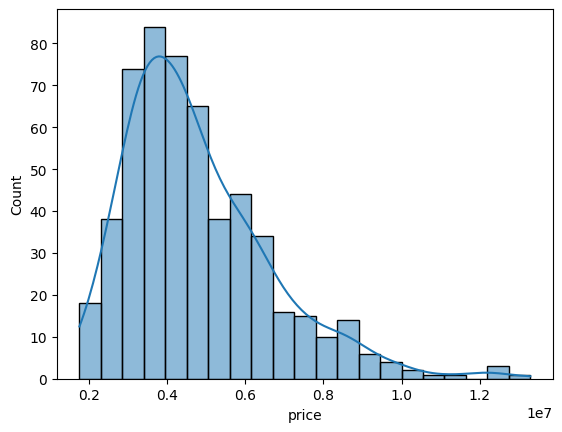

In [ ]:
sns.histplot(df['price'], kde=True)
plt.show()

In [ ]:
# to know it is skewed or not
df['price'].skew()
# >1 right skew,<1 left skew ,0=no skew

np.float64(1.2122388370279802)

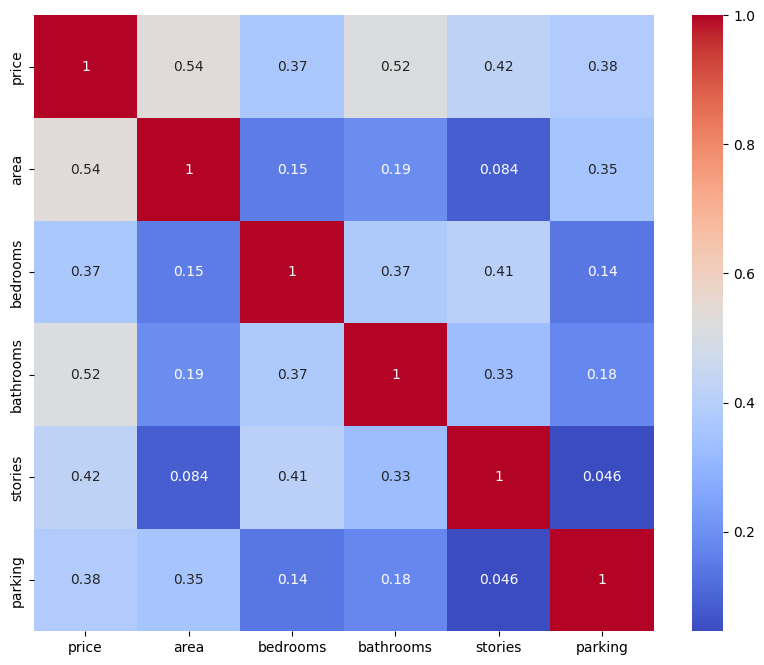

In [ ]:
#correlation -> identifies imp features
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
#Converts text → numbers
df = pd.get_dummies(df, drop_first=True)

In [ ]:
# train-test-split
X = df.drop('price', axis=1)
y = np.log(df['price'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# linear regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

preds_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, preds_lr))
r2_lr = r2_score(y_test, preds_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression RMSE: 0.2515821402917184
Linear Regression R2: 0.6722047299637571


In [ ]:
# random forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

preds_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, preds_rf))
r2_rf = r2_score(y_test, preds_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

Random Forest RMSE: 0.26629884242786184
Random Forest R2: 0.632733239040493


In [ ]:
print("LR RMSE:", rmse_lr)
print("RF RMSE:", rmse_rf)

LR RMSE: 0.2515821402917184
RF RMSE: 0.26629884242786184


In [ ]:
#hyper parameter tuning
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [8, 10, 12],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 'log2']
}
# by tightening this values it reduces model complexity
grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}


In [ ]:
best_rf = grid.best_estimator_

final_preds = best_rf.predict(X_test)

rmse_final = np.sqrt(mean_squared_error(y_test, final_preds))
r2_final = r2_score(y_test, final_preds)

print("Final RMSE:", rmse_final)
print("Final R2:", r2_final)

Final RMSE: 0.2693953356537303
Final R2: 0.6241425078808265


In [ ]:
#Use Cross Validation (instead of single split)
from sklearn.model_selection import cross_val_score
import numpy as np

lr_scores = cross_val_score(lr, X, y, cv=5, scoring='neg_root_mean_squared_error')
rf_scores = cross_val_score(rf, X, y, cv=5, scoring='neg_root_mean_squared_error')

print("LR CV RMSE:", -lr_scores.mean())
print("RF CV RMSE:", -rf_scores.mean())

LR CV RMSE: 0.2532035838798036
RF CV RMSE: 0.3017929768330345


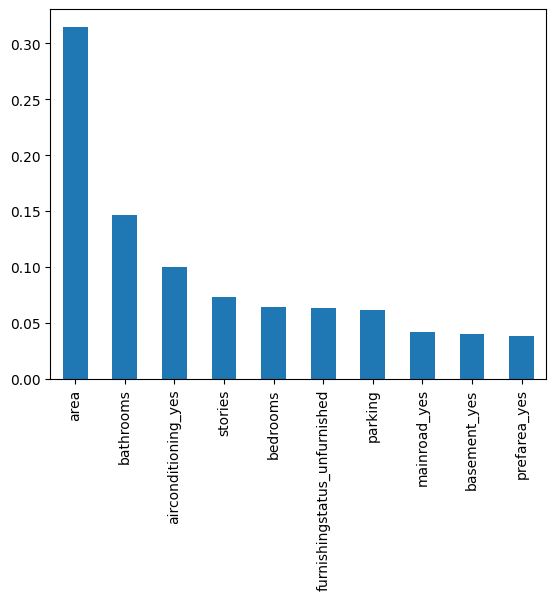

In [ ]:
# to check good features
importances = best_rf.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

feat_imp.head(10).plot(kind='bar')
plt.show()

In [ ]:
#Feature pruning (you likely have noise)You probably have too many weak features after encoding.
feat_imp = pd.Series(best_rf.feature_importances_, index=X.columns)
important_features = feat_imp[feat_imp > 0.01].index

X = X[important_features]

In [ ]:
# create new features
df['area_per_room'] = df['area'] / df['bedrooms']
df['price_per_sqft'] = df['price'] / df['area']
df['bedroom_density'] = df['bedrooms'] / df['area']
df['bath_per_bed'] = df['bathrooms'] / df['bedrooms']
#Combine features:
df['total_rooms'] = df['bedrooms'] + df['bathrooms']

In [ ]:
# overfitting check
train_preds = best_rf.predict(X_train)

train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
test_rmse = rmse_final

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train RMSE: 0.15596682691529526
Test RMSE: 0.2693953356537303


In [ ]:
y = np.log1p(y)

In [ ]:
# Gradientboostregressor algo
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3
)

gb.fit(X_train, y_train)

preds = gb.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R2:", r2_score(y_test, preds))

RMSE: 0.2528525974448819
R2: 0.6688857236627601


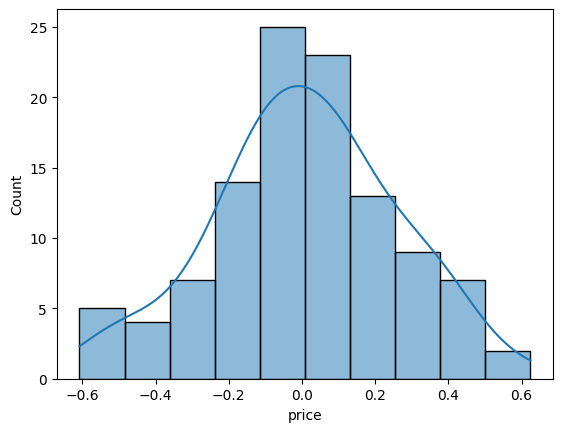

In [ ]:
#If residuals look random → linear model is valid
residuals = y_test - preds_lr

sns.histplot(residuals, kde=True)
plt.show()

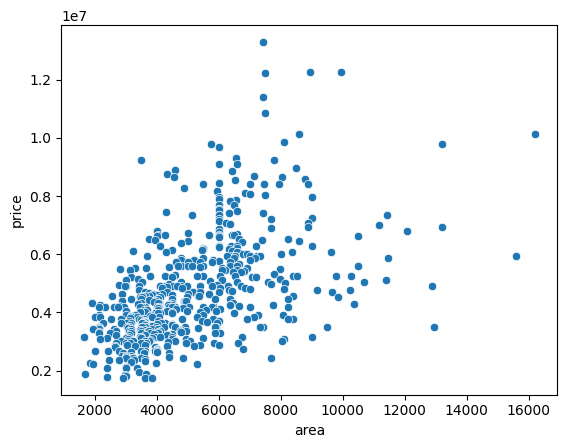

In [ ]:
sns.scatterplot(x=df['area'], y=df['price'])
plt.show()

**Train final model,adding user input**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)

LinearRegression()

In [ ]:
# create prediction function
def predict_price(input_data):
    # Convert to DataFrame
    input_df = pd.DataFrame([input_data])

    # Align columns
    input_df = input_df.reindex(columns=X.columns, fill_value=0)

    # Scale
    input_scaled = scaler.transform(input_df)

    # Predict
    prediction = model.predict(input_scaled)
    # used log transform in model
    return np.expm1(prediction[0])

In [ ]:
# give input and test
sample_house = {
    'area': 3000,
    'bedrooms': 3,
    'bathrooms': 2,
    'stories': 2,
    'parking': 1

}
price = predict_price(sample_house)

print("Predicted Price:", price)


Predicted Price: 3829759.0976982843


In [ ]:
# interactive prediction

area = float(input("Enter area: "))
bedrooms = int(input("Enter bedrooms: "))
bathrooms = int(input("Enter bathrooms: "))

sample = {
    'area': area,
    'bedrooms': bedrooms,
    'bathrooms': bathrooms
}

print("Predicted Price:", predict_price(sample))

Enter area: 400
Enter bedrooms: 3
Enter bathrooms: 2
Predicted Price: 2673230.8970569465
